In [224]:
#imports
%matplotlib inline
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import importlib
import sys
import os
from astropy.cosmology import Planck18 as cosmo
import ast




In [241]:
# --- User toggle ---
Cristina = True
Shar = not Cristina 

# --- System Configurations ---

if Cristina:
    print("[CONFIG] Using Cristina's local MacBook setup")
    sys.path.insert(0, "/Users/andradenebula/Documents/Research/Transient_Metrics/Multi_Transient_Metrics_Hub")
    os.environ["RUBIN_SIM_DATA_DIR"] = "/Users/andradenebula/rubin_sim_data"
    db_dir = "/Users/andradenebula/Documents/Research/Transient_Metrics/Multi_Transient_Metrics_Hub"

elif Shar:
    print("[CONFIG] Using Shar's Dirac server setup")
    sys.path.insert(0, "/lustre/lrspec/metrics")
    sys.path.insert(0, "/home/3155/metrics/Multi_Transient_Metrics_Hub")
    os.environ["RUBIN_SIM_DATA_DIR"] = "/lustre/lrspec/metrics/rubin_sim_data"
    db_dir = "/lustre/lrspec/metrics"

# Shared config
sys.path.append(os.path.abspath(".."))  # For shared_utils


[CONFIG] Using Cristina's local MacBook setup


In [243]:

import os
print(os.getcwd())


/Users/andradenebula/Documents/Research/Transient_Metrics/Multi_Transient_Metrics_Hub/LFBOT


In [384]:
#this happens twice because idk why but it only works like that
#...you still have to run it twice if it gives warnings
# C: Make sure you save your metric file before running. 

metric_filename = "local_LFBOTmetric"
s_u = "shared_utils"

# --- Reload metric module ---
if metric_filename in sys.modules:
    del sys.modules[metric_filename]
metric = __import__(metric_filename)
importlib.reload(metric)

# --- Reload shared_utils module ---
if s_u in sys.modules:
    del sys.modules[s_u]
shared_utils = __import__(s_u)
importlib.reload(shared_utils)

print(f"[INFO] Loaded metric module: {metric_filename}")
print(f"[INFO] Loaded shared_utils module")



[INFO] Loaded metric module: local_LFBOTmetric
[INFO] Loaded shared_utils module


In [386]:
#metric configurations

use_log_time = False

#control whether we generate new files
generate_new_templates = True
generate_new_pop = True
make_debug_plots = False #toggle whether or not the pop generation makes plots

#population variables
rate_density = 1e-8

# apply None for non-use case 
z_min, z_max = 0.00226, 0.3
dmin, dmax = None, None

#other
gal_lat_cut = None #latitude cut, for Galactic phenomena
use_extinction = True
t_start = 1 #start time in days
t_end = 3652

# Whether to remove Metric_temp_* folders after running
clean_temp = True  # <- NEW toggle

#cadence variables
cadences = ['four_roll_v4.3.1_10yrs', 'baseline_v4.3.1_10yrs']
ignore_triples = False #turn this to true to ignore triples
filters = ['u', 'g', 'r', 'i', 'z', 'y'] #doesn't work rn i think but
#if we wanted to look at less filters then we would adjust that here

# Standardized output paths for this science case
paths = metric.get_output_paths(case_label="LFBOT")  # <- can change to 'KNe' etc.

storage_dir = paths['storage_dir']
templates_file = paths['templates_file']
pop_file = paths['pop_file']


In [388]:
#load and/or generate light curves
shared_lc_model = metric.load_or_generate_templates(num_samples=1, num_lightcurves=1,
    templates_file=templates_file,
    generate_new=generate_new_templates
)

[INFO] Generating 1 light curve templates.
m0:_g:-20.06510987861009,t0:5,rise:1.2374764894421177,fade:2.2
Saved synthetic LFBOT light curve templates to /Users/andradenebula/Documents/Research/Transient_Metrics/Multi_Transient_Metrics_Hub/output/LFBOT/LFBOT_templates.pkl
Loaded LFBOT templates from /Users/andradenebula/Documents/Research/Transient_Metrics/Multi_Transient_Metrics_Hub/output/LFBOT/LFBOT_templates.pkl


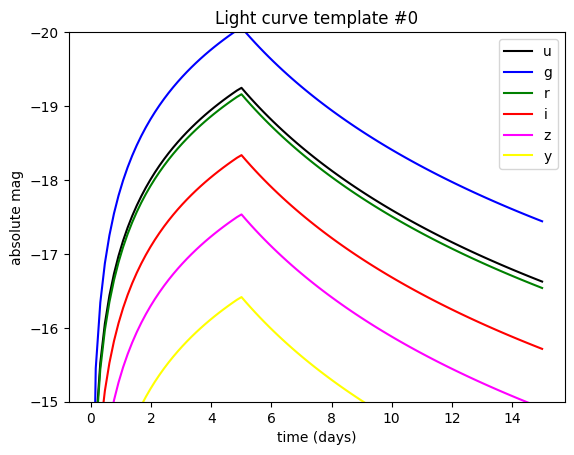

In [390]:
#plot light curves from pkl file if desired
shared_utils.plot_some_lcs_from_pkl(templates_file, num=1, use_log_time = use_log_time)

In [256]:
# Load or generate population slicer
slicer = metric.load_or_generate_population(
    t_start=t_start,
    t_end=t_end,
    d_min=dmin,
    d_max=dmax,
    z_min=z_min,
    z_max=z_max,
    seed=42,
    num_lightcurves=1000,
    gal_lat_cut=gal_lat_cut,
    rate_density=rate_density,
    pop_file=pop_file,
    generate_new=generate_new_pop,
    make_debug_plots=make_debug_plots
)


[INFO] Generating LFBOT population and saving to /Users/andradenebula/Documents/Research/Transient_Metrics/Multi_Transient_Metrics_Hub/output/LFBOT/LFBOT_population.pkl
[INFO] z_min = 0.00226 → d_min = 10.008475172186687 Mpc
[INFO] z_max = 0.30000 → d_max = 1232.706667272352661 Mpc
Simulated 775 LFBOT events using rate_density = 1.0e-08
Saved LFBOT population to /Users/andradenebula/Documents/Research/Transient_Metrics/Multi_Transient_Metrics_Hub/output/LFBOT/LFBOT_population.pkl


## All 10 years

In [403]:
bbfluratios=[0.47184822835586304,
 1.0,
 0.4356131668415372,
 0.20399584045639102,
 0.09743514963840874,
 0.0347938320584038]

filters = ['u','g','r','i','z','y']
# Assuming bbfluratios has already been computed from your code
mag_offsets = -2.5 * np.log10(bbfluratios)

# Optionally normalize to g = 22 mag
g_mag = 22
magnitudes = {f: g_mag + dm for f, dm in zip(filters, mag_offsets)}
magnitudes


{'u': np.float64(22.81549417813454),
 'g': np.float64(22.0),
 'r': np.float64(22.902247504337247),
 'i': np.float64(23.72594671973493),
 'z': np.float64(24.528210858825013),
 'y': np.float64(25.64624434274951)}

In [393]:
#run detection metric
df_obs_arr = shared_utils.run_detect(metric, slicer, cadences, shared_lc_model, db_dir, storage_dir, debug=True, plot=True, clean_temp=clean_temp, use_extinction=use_extinction)


--- Running four_roll_v4.3.1_10yrs ---
m0:_g:-20.06510987861009,t0:5,rise:1.2374764894421177,fade:2.2
m0:_g:-20.25657992735159,t0:5,rise:0.46189903274721145,fade:2.2
m0:_g:-20.097150745024116,t0:5,rise:2.018644686873146,fade:2.2
m0:_g:-20.874035155261083,t0:5,rise:1.0842955545233077,fade:2.2
m0:_g:-20.39033719979834,t0:5,rise:2.1012136298593673,fade:2.2
m0:_g:-21.43190319553806,t0:5,rise:1.4978157707856283,fade:2.2
m0:_g:-19.930922070018546,t0:5,rise:1.671244898024646,fade:2.2
m0:_g:-21.113685079675328,t0:5,rise:2.434070554888532,fade:2.2
m0:_g:-20.054041257315596,t0:5,rise:0.687937092666927,fade:2.2
m0:_g:-21.89049058553193,t0:5,rise:0.5971513571519826,fade:2.2
m0:_g:-20.138094610230457,t0:5,rise:2.4268968979769725,fade:2.2
m0:_g:-21.073850734912828,t0:5,rise:1.3065005753705679,fade:2.2
m0:_g:-21.67519623666132,t0:5,rise:1.320336084008351,fade:2.2
m0:_g:-20.325465013293723,t0:5,rise:1.2335918174627443,fade:2.2
m0:_g:-20.249337244994376,t0:5,rise:0.9528249431095924,fade:2.2
m0:_g:-19.

IndexError: list index out of range

In [395]:
#choose what to run in run_multi_metrics
# we can remove historical if we want
multi_metrics = metric.get_multi_metrics(shared_lc_model, include=['detect', 'characterize', 'spec_trigger'], use_extinction=use_extinction)


m0:_g:-20.06510987861009,t0:5,rise:1.2374764894421177,fade:2.2
m0:_g:-20.25657992735159,t0:5,rise:0.46189903274721145,fade:2.2
m0:_g:-20.097150745024116,t0:5,rise:2.018644686873146,fade:2.2
m0:_g:-20.874035155261083,t0:5,rise:1.0842955545233077,fade:2.2
m0:_g:-20.39033719979834,t0:5,rise:2.1012136298593673,fade:2.2
m0:_g:-21.43190319553806,t0:5,rise:1.4978157707856283,fade:2.2
m0:_g:-19.930922070018546,t0:5,rise:1.671244898024646,fade:2.2
m0:_g:-21.113685079675328,t0:5,rise:2.434070554888532,fade:2.2
m0:_g:-20.054041257315596,t0:5,rise:0.687937092666927,fade:2.2
m0:_g:-21.89049058553193,t0:5,rise:0.5971513571519826,fade:2.2
m0:_g:-20.138094610230457,t0:5,rise:2.4268968979769725,fade:2.2
m0:_g:-21.073850734912828,t0:5,rise:1.3065005753705679,fade:2.2
m0:_g:-21.67519623666132,t0:5,rise:1.320336084008351,fade:2.2
m0:_g:-20.325465013293723,t0:5,rise:1.2335918174627443,fade:2.2
m0:_g:-20.249337244994376,t0:5,rise:0.9528249431095924,fade:2.2
m0:_g:-19.988089106257995,t0:5,rise:1.121826352817

In [397]:
shared_utils.run_multi_metrics(multi_metrics, slicer, cadences, shared_lc_model, db_dir, storage_dir, ignore_triples=False, plot=True, clean_temp=clean_temp, use_extinction=use_extinction)


--- Running four_roll_v4.3.1_10yrs ---
Failed at slice_point {'idxs': array([1839235, 1839184, 1807084, 1807135, 1413977,   11564, 1002778,
       1827927, 1797020,  584988,     142, 1447549, 1983854,  163590,
        953671, 1827876, 1577471,  585035, 1577522,  591137,   11513,
        171374,   18033,  414045,      91, 1763378,  624863, 1975314,
       1788162, 1415340,   17982,  585012,  178081, 1413926, 1983803,
        953644, 1454899,  584965,  624812, 1415294,  182207,  182258,
        110038,  163570,  178132, 1002829,  414096, 1996894,  626302,
       1797071, 1517239,  372360,  147333,  171323, 1517290,  626251,
        372309,  110016, 1454923, 1788213, 1969594, 1814203, 1969543,
       1814152,  611434,  784421,  997547, 1574264,  630806, 1579162,
        975404, 1419464, 1000146, 1000095, 1574315, 1002041,  960303,
       1378450, 1579111,  184295, 1838380,  630755, 1432185,  588538,
        217953,  976068,  212613, 1391917, 1007559, 1419413,  997598,
        588514,  96

IndexError: list index out of range

In [ ]:

# Combine obs_records from your metric(s)
all_records = []
for m in multi_metrics:
    if hasattr(m, 'obs_records'):
        all_records.extend(m.obs_records.values())

# Convert to DataFrame
obs_data = pd.DataFrame(all_records)
detected_df = obs_data[obs_data['detected'] == True]

detected_df = obs_data[obs_data['detected'] == True]
theta_rad = detected_df['theta_obs']
theta_deg = np.degrees(theta_rad)

plt.hist(theta_deg, bins=30, color='steelblue', edgecolor='black')
plt.xlabel('Inclination angle (deg)')
plt.ylabel('Number of detected LFBOTs')
plt.title('Detected LFBOTs Inclination Angle Distribution')
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 4))
plt.hist(detected_df['peak_mag'], bins=30, edgecolor='black', color='red')
plt.xlabel("Apparent Peak Magnitude")
plt.ylabel("Number of Detected LFBOTs")
plt.title("Distribution of Apparent Peak Magnitudes (Detected LFBOTs)")
plt.gca().invert_xaxis()  # optional: brightest on the left
plt.grid(True)
plt.tight_layout()
plt.show()


In [ ]:


# Parse the observation strings back into arrays
def to_array(col):
    return col.apply(lambda x: np.array(ast.literal_eval(x)) if isinstance(x, str) else np.array(x) if isinstance(x, list) else np.array([]))

# Extract magnitudes where SNR >= 5
def get_detected_mags(mags, snrs):
    try:
        mags = np.array(mags)
        snrs = np.array(snrs)
        if len(mags) != len(snrs):
            return []
        return mags[snrs >= 5.0]
    except Exception as e:
        print(f"[DEBUG] Issue with mags/snrs: {e}")
        return []

detected_df = obs_data[obs_data['detected'] == True].copy()  # Use .copy() here

detected_df.loc[:, 'mag_obs'] = to_array(detected_df['mag_obs'])
detected_df.loc[:, 'snr_obs'] = to_array(detected_df['snr_obs'])

detected_df.loc[:, 'det_mags'] = detected_df.apply(
    lambda row: get_detected_mags(row['mag_obs'], row['snr_obs']), axis=1
)

all_detected_mags = np.concatenate(detected_df['det_mags'].values)

plt.figure(figsize=(8, 4))
plt.hist(all_detected_mags, bins=30, edgecolor='black', color='darkorange')
plt.xlabel("Magnitude at Detection (SNR ≥ 5)")
plt.ylabel("Number of Observations")
plt.title("Distribution of Magnitudes at Detection (LFBOTs)")
plt.gca().invert_xaxis()  # brighter on the left
plt.grid(True)
plt.tight_layout()
plt.show()

